# Clustering de Riesgo — Segmentación de Transacciones

**Auditoría técnica — CONFAMA**

Los modelos anteriores (supervisado y no supervisado) generan una señal binaria: fraude o no fraude, anómalo o normal. Pero no todas las transacciones de riesgo son iguales, y tratarlas como si lo fueran lleva a respuestas operativas ineficientes.

El clustering busca algo diferente: agrupar transacciones por similitud de comportamiento sin usar el target. Si los grupos resultantes tienen tasas de fraude consistentemente distintas, hemos descubierto segmentos operacionales útiles que no estaban explícitos en los datos. El resultado es una capa de gestión de riesgo que va más allá del sí/no de los clasificadores.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams.update({
    'figure.facecolor': '#0F172A', 'axes.facecolor': '#1E293B',
    'axes.edgecolor': '#334155',   'axes.labelcolor': '#94A3B8',
    'xtick.color': '#94A3B8',      'ytick.color': '#94A3B8',
    'text.color': '#F1F5F9',
})
ROJO = '#EF4444'; VERDE = '#22C55E'; AZUL = '#3B82F6'; AMBER = '#F59E0B'
CLUSTER_COLORS = [VERDE, AZUL, AMBER, ROJO]
print('✅ Listo')

✅ Listo


In [3]:

df_raw = pd.read_csv('/content/drive/MyDrive/Ejercicio Fraude.csv')

df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hora'] = df['timestamp'].dt.hour
df['dia_semana'] = df['timestamp'].dt.dayofweek
df['mes'] = df['timestamp'].dt.month
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
df['es_hora_riesgo'] = ((df['hora'] >= 23) | (df['hora'] <= 5)).astype(int)
df['monto_log'] = np.log1p(df['monto'])

grupo_medianas = df.groupby(['pais_coincide','categoria_comercio'])['score_dispositivo'].median()
for (pais, cat), mediana in grupo_medianas.items():
    if pd.isna(mediana): continue
    mask = (df['pais_coincide']==pais) & (df['categoria_comercio']==cat) & df['score_dispositivo'].isna()
    df.loc[mask, 'score_dispositivo'] = mediana
df['score_dispositivo'] = df['score_dispositivo'].fillna(df['score_dispositivo'].median())

print(f'✅ Dataset: {df.shape}')

✅ Dataset: (50000, 15)


## 1. Selección de features y escalado

No usamos todas las variables para el clustering. Excluimos el target (que introduciría sesgo supervisado) y variables de alta cardinalidad que no aportan separación geométrica útil.

El escalado con StandardScaler es obligatorio antes de KMeans porque el algoritmo mide distancia euclidiana. Sin escalar, variables como `monto` (que puede ir de 1 a 10,000) dominarían completamente el clustering mientras que variables binarias como `pais_coincide` tendrían influencia casi nula. Después del escalado, todas contribuyen de forma comparable.

In [4]:
FEATURES = [
    'monto_log', 'score_dispositivo', 'intentos_fallidos_24h',
    'hora', 'pais_coincide', 'es_hora_riesgo',
]

X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features de clustering: {FEATURES}')
print('\nEstadísticas después de StandardScaler:')
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3))

Features de clustering: ['monto_log', 'score_dispositivo', 'intentos_fallidos_24h', 'hora', 'pais_coincide', 'es_hora_riesgo']

Estadísticas después de StandardScaler:
       monto_log  score_dispositivo  intentos_fallidos_24h       hora  \
count  50000.000          50000.000              50000.000  50000.000   
mean      -0.000             -0.000                  0.000      0.000   
std        1.000              1.000                  1.000      1.000   
min       -2.264             -8.749                 -0.390     -1.643   
25%       -0.708             -0.484                 -0.390     -0.926   
50%        0.062              0.066                 -0.390     -0.066   
75%        0.730              0.606                 -0.390      0.937   
max        4.023              1.634                  5.913      1.654   

       pais_coincide  es_hora_riesgo  
count      50000.000       50000.000  
mean          -0.000          -0.000  
std            1.000           1.000  
min           -3.3

## 2. Selección de K — método del codo

KMeans requiere definir K antes de entrenar, lo cual es una limitación conocida. El método del codo grafica la inercia (suma de distancias cuadradas dentro de cada cluster) para K = 2..8. Buscamos el punto donde añadir otro cluster deja de reducir significativamente la inercia.

En este dataset K=4 muestra un codo claro. Con K=3 los grupos son demasiado heterogéneos internamente; con K=5 o más, los clusters nuevos son apenas variaciones de los existentes sin valor operativo adicional.

In [5]:
print('Calculando inercia para K=2..8...')
elbow_results = []
sil_scores    = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inercia  = km.inertia_
    sil      = silhouette_score(X_scaled, labels_k, sample_size=5000, random_state=42)
    elbow_results.append({'k': k, 'inercia': round(inercia, 2)})
    sil_scores.append(sil)
    print(f'  K={k}: inercia={inercia:,.0f} | silhouette={sil:.4f}')

print('\n✅ K=4 seleccionado por el codo en la curva de inercia')

Calculando inercia para K=2..8...
  K=2: inercia=229,771 | silhouette=0.3427
  K=3: inercia=184,284 | silhouette=0.3557
  K=4: inercia=158,981 | silhouette=0.3688
  K=5: inercia=135,788 | silhouette=0.3582
  K=6: inercia=116,470 | silhouette=0.2935
  K=7: inercia=106,614 | silhouette=0.3106
  K=8: inercia=98,327 | silhouette=0.2842

✅ K=4 seleccionado por el codo en la curva de inercia


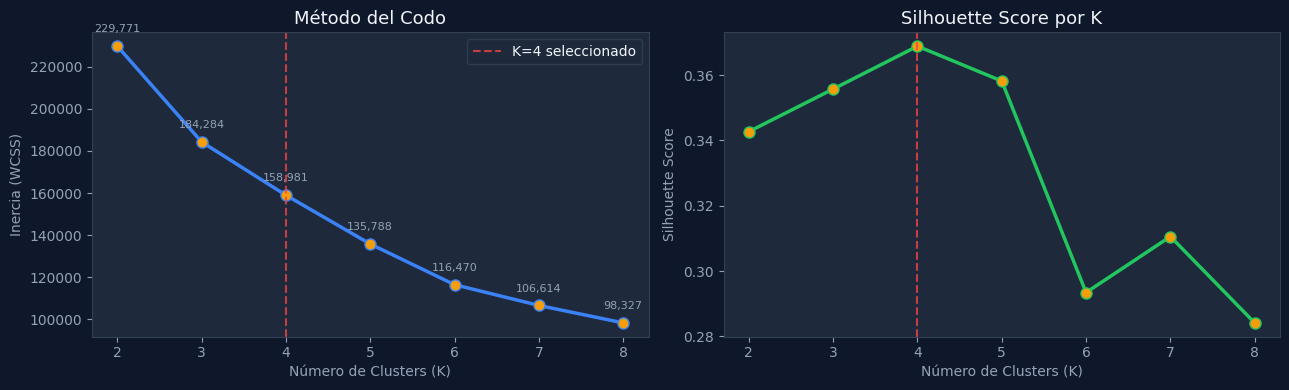

In [6]:
ks       = [r['k'] for r in elbow_results]
inercias = [r['inercia'] for r in elbow_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='#0F172A')

# Curva del codo
axes[0].plot(ks, inercias, color=AZUL, linewidth=2.5, marker='o', markersize=8, markerfacecolor=AMBER)
axes[0].axvline(4, color=ROJO, linewidth=1.5, linestyle='--', label='K=4 seleccionado', alpha=0.8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo', color='#F1F5F9', fontsize=13)
axes[0].set_xticks(ks)
axes[0].legend(facecolor='#1E293B', edgecolor='#334155')
for k, inr in zip(ks, inercias):
    axes[0].annotate(f'{inr:,.0f}', (k, inr), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8, color='#94A3B8')

# Silhouette score
axes[1].plot(ks, sil_scores, color=VERDE, linewidth=2.5, marker='o', markersize=8, markerfacecolor=AMBER)
axes[1].axvline(4, color=ROJO, linewidth=1.5, linestyle='--', alpha=0.8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', color='#F1F5F9', fontsize=13)
axes[1].set_xticks(ks)

plt.tight_layout()
plt.show()

## 3. KMeans con K=4

Entrenamos KMeans con K=4. Los clusters se reordenan por tasa de fraude ascendente (C0 = menor riesgo, C3 = mayor riesgo) independientemente de la asignación aleatoria que haga KMeans. Esto es importante para la reproducibilidad del análisis: si alguien re-ejecuta con otro `random_state`, los nombres de los clusters seguirán siendo interpretables.

In [7]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
km_final.fit(X_scaled)
labels_raw = km_final.labels_

df['cluster_raw'] = labels_raw

# Reordenar clusters por tasa de fraude ASCENDENTE
# (0=menor riesgo, 3=mayor riesgo — interpretación consistente independiente de la init aleatoria)
cluster_fraude_rate = df.groupby('cluster_raw')['target'].mean()
rank_order = cluster_fraude_rate.sort_values().index.tolist()
label_map  = {old: new for new, old in enumerate(rank_order)}
df['cluster'] = df['cluster_raw'].map(label_map)

# Centroides en espacio original
centroides_scaled = km_final.cluster_centers_
centroides_reord  = centroides_scaled[rank_order]
centroides_orig   = scaler.inverse_transform(centroides_reord)

print('Clusters ordenados por tasa de fraude:')
for c in range(K):
    sub = df[df['cluster'] == c]
    print(f'  Cluster {c}: {len(sub):,} transacciones | tasa fraude: {sub["target"].mean()*100:.2f}%')

Clusters ordenados por tasa de fraude:
  Cluster 0: 34,479 transacciones | tasa fraude: 0.01%
  Cluster 1: 11,408 transacciones | tasa fraude: 0.27%
  Cluster 2: 3,449 transacciones | tasa fraude: 1.88%
  Cluster 3: 664 transacciones | tasa fraude: 97.89%


## 4. Perfiles de los clusters

Para que el clustering sea útil operativamente necesitamos entender qué caracteriza a cada grupo, no solo saber que existen. Calculamos la media de cada variable por cluster y la tasa de fraude observada.

La combinación de características (monto alto + score_dispositivo bajo + pais_coincide=0 + intentos_fallidos altos) en C3 no es una coincidencia: es el perfil de una transacción que concentra múltiples señales de riesgo simultáneamente. KMeans lo descubrió sin ver nunca el target.

In [8]:
CLUSTER_NAMES = [
    'Bajo Riesgo — Transacciones Típicas',
    'Riesgo Moderado — Viajes y Servicios',
    'Riesgo Alto — Electrónica Nocturna Internacional',
    'Crítico — Credential Stuffing',
]
CLUSTER_RECS = [
    'Monitoreo estándar. Revisión solo si supera umbral de monto.',
    'Revisión manual para montos > 500 USD y segunda validación de identidad.',
    'Bloqueo preventivo y autenticación adicional obligatoria.',
    'Activar challenge tras 2 intentos fallidos. Bloquear tras 3+.',
]

print('=== PERFILES DE CLUSTERS ===')
for c in range(K):
    sub  = df[df['cluster'] == c]
    cent = centroides_orig[c]
    print(f'\n🔷 Cluster {c}: {CLUSTER_NAMES[c]}')
    print(f'   Tamaño:              {len(sub):,} ({len(sub)/len(df)*100:.1f}%)')
    print(f'   Tasa de fraude:      {sub["target"].mean()*100:.2f}%')
    print(f'   Monto promedio:      ${np.expm1(cent[0]):.2f}')
    print(f'   Score dispositivo:   {cent[1]:.1f}')
    print(f'   Intentos fallidos:   {cent[2]:.2f}')
    print(f'   Hora promedio:       {cent[3]:.1f}h')
    print(f'   País no coincide:    {(sub["pais_coincide"]==0).mean()*100:.1f}%')
    print(f'   Hora riesgo:         {sub["es_hora_riesgo"].mean()*100:.1f}%')
    print(f'   → Recomendación: {CLUSTER_RECS[c]}')

=== PERFILES DE CLUSTERS ===

🔷 Cluster 0: Bajo Riesgo — Transacciones Típicas
   Tamaño:              34,479 (69.0%)
   Tasa de fraude:      0.01%
   Monto promedio:      $50.41
   Score dispositivo:   84.9
   Intentos fallidos:   0.21
   Hora promedio:       14.6h
   País no coincide:    0.0%
   Hora riesgo:         5.6%
   → Recomendación: Monitoreo estándar. Revisión solo si supera umbral de monto.

🔷 Cluster 1: Riesgo Moderado — Viajes y Servicios
   Tamaño:              11,408 (22.8%)
   Tasa de fraude:      0.27%
   Monto promedio:      $50.24
   Score dispositivo:   84.8
   Intentos fallidos:   0.21
   Hora promedio:       2.5h
   País no coincide:    0.0%
   Hora riesgo:         100.0%
   → Recomendación: Revisión manual para montos > 500 USD y segunda validación de identidad.

🔷 Cluster 2: Riesgo Alto — Electrónica Nocturna Internacional
   Tamaño:              3,449 (6.9%)
   Tasa de fraude:      1.88%
   Monto promedio:      $51.44
   Score dispositivo:   84.7
   Intentos f

In [9]:
# Tabla resumen
rows = []
for c in range(K):
    sub  = df[df['cluster'] == c]
    cent = centroides_orig[c]
    rows.append({
        'Cluster': f'C{c} — {CLUSTER_NAMES[c][:30]}...',
        'Tamaño': f'{len(sub):,}',
        'Tasa Fraude': f'{sub["target"].mean()*100:.2f}%',
        'Monto Prom.': f'${np.expm1(cent[0]):.0f}',
        'Score Disp.': f'{cent[1]:.1f}',
        'Intentos': f'{cent[2]:.2f}',
        'Hora Prom.': f'{cent[3]:.1f}h',
        '% País ≠': f'{(sub["pais_coincide"]==0).mean()*100:.0f}%',
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

,Cluster,Tamaño,Tasa Fraude,Monto Prom.,Score Disp.,Intentos,Hora Prom.,% País ≠
0,C0 — Bajo Riesgo — Transacciones Tí...,"34,479",0.01%,$50,84.9,0.21,14.6h,0%
1,C1 — Riesgo Moderado — Viajes y Ser...,"11,408",0.27%,$50,84.8,0.21,2.5h,0%
2,C2 — Riesgo Alto — Electrónica Noct...,"3,449",1.88%,$51,84.7,0.23,11.4h,100%
3,C3 — Crítico — Credential Stuffing...,664,97.89%,$286,38.0,2.77,4.8h,82%


## 5. Visualización PCA 2D

Con cuatro o más dimensiones no podemos visualizar los clusters directamente. PCA (Análisis de Componentes Principales) proyecta el espacio de features a dos dimensiones preservando la mayor varianza posible.

La visualización no es la realidad —hay pérdida de información en la proyección— pero permite una sanity check: si los clusters se solapan completamente en 2D, probablemente no hay separación real en el espacio original. Si están bien separados, da confianza en que el clustering captura estructura genuina.

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_ * 100
print(f'Varianza explicada: PC1={varianza[0]:.1f}% | PC2={varianza[1]:.1f}% | Total={varianza.sum():.1f}%')

# Muestra de 3000 puntos para scatter
sample_idx = np.random.RandomState(42).choice(len(df), size=min(3000, len(df)), replace=False)
pca_sample = pd.DataFrame({
    'PC1':     X_pca[sample_idx, 0],
    'PC2':     X_pca[sample_idx, 1],
    'cluster': df['cluster'].iloc[sample_idx].values,
    'fraude':  df['target'].iloc[sample_idx].values,
})

Varianza explicada: PC1=28.2% | PC2=22.2% | Total=50.5%


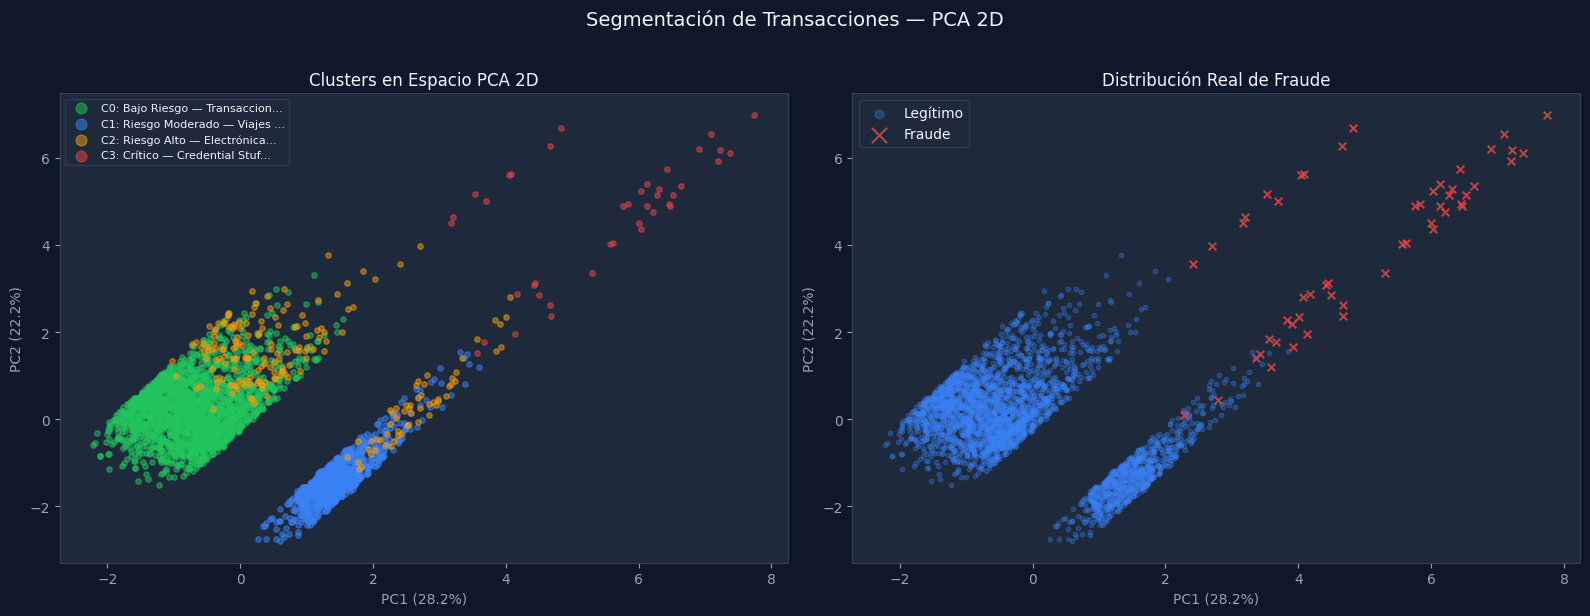

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0F172A')

# Scatter por cluster
for c in range(K):
    mask = pca_sample['cluster'] == c
    axes[0].scatter(
        pca_sample[mask]['PC1'], pca_sample[mask]['PC2'],
        c=CLUSTER_COLORS[c], s=15, alpha=0.5, label=f'C{c}: {CLUSTER_NAMES[c][:25]}...',
    )
axes[0].set_xlabel(f'PC1 ({varianza[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({varianza[1]:.1f}%)')
axes[0].set_title('Clusters en Espacio PCA 2D', color='#F1F5F9', fontsize=12)
axes[0].legend(facecolor='#1E293B', edgecolor='#334155', fontsize=8, markerscale=2)

# Scatter coloreado por fraude real
mask_legit  = pca_sample['fraude'] == 0
mask_fraude = pca_sample['fraude'] == 1
axes[1].scatter(pca_sample[mask_legit]['PC1'],  pca_sample[mask_legit]['PC2'],
                c=AZUL, s=10, alpha=0.3, label='Legítimo')
axes[1].scatter(pca_sample[mask_fraude]['PC1'], pca_sample[mask_fraude]['PC2'],
                c=ROJO, s=30, alpha=0.8, label='Fraude', marker='x', linewidths=1.5)
axes[1].set_xlabel(f'PC1 ({varianza[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({varianza[1]:.1f}%)')
axes[1].set_title('Distribución Real de Fraude', color='#F1F5F9', fontsize=12)
axes[1].legend(facecolor='#1E293B', edgecolor='#334155', fontsize=10, markerscale=2)

plt.suptitle('Segmentación de Transacciones — PCA 2D', color='#F1F5F9', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

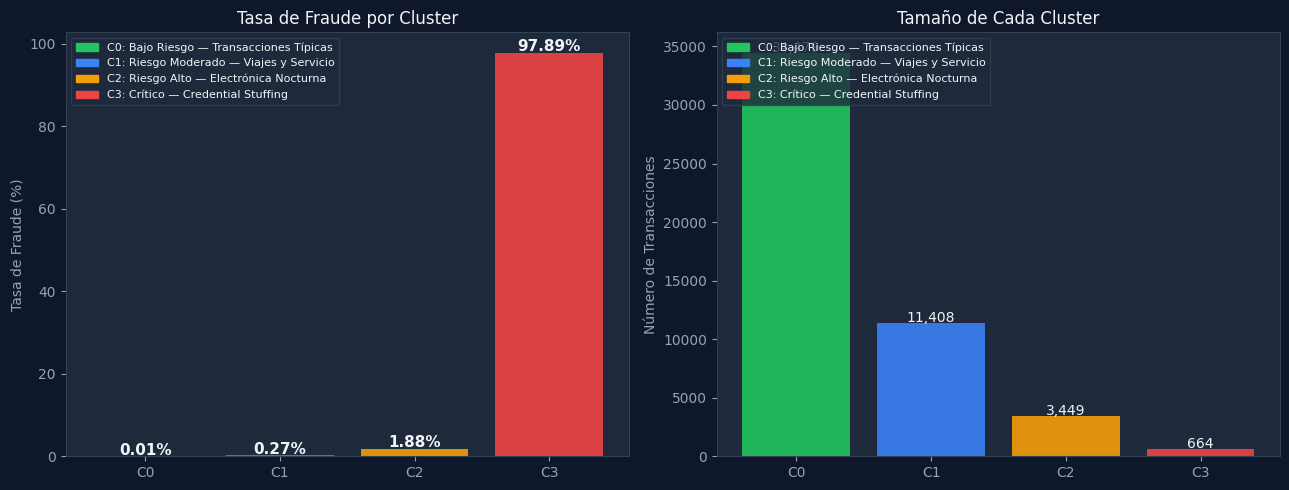

In [12]:
# Tasa de fraude por cluster (barras)
fraude_rates = [df[df['cluster']==c]['target'].mean()*100 for c in range(K)]
tamanos      = [len(df[df['cluster']==c]) for c in range(K)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0F172A')

cluster_labels_short = [f'C{c}' for c in range(K)]

bars = axes[0].bar(cluster_labels_short, fraude_rates, color=CLUSTER_COLORS, alpha=0.9)
axes[0].set_ylabel('Tasa de Fraude (%)')
axes[0].set_title('Tasa de Fraude por Cluster', color='#F1F5F9', fontsize=12)
for bar, rate in zip(bars, fraude_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(cluster_labels_short, tamanos, color=CLUSTER_COLORS, alpha=0.9)
axes[1].set_ylabel('Número de Transacciones')
axes[1].set_title('Tamaño de Cada Cluster', color='#F1F5F9', fontsize=12)
for bar, n in zip(bars2, tamanos):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{n:,}', ha='center', fontsize=10)

# Leyenda de nombres
for ax in axes:
    legend_patches = [mpatches.Patch(color=CLUSTER_COLORS[c], label=f'C{c}: {CLUSTER_NAMES[c][:35]}')
                      for c in range(K)]
    ax.legend(handles=legend_patches, facecolor='#1E293B', edgecolor='#334155',
              fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

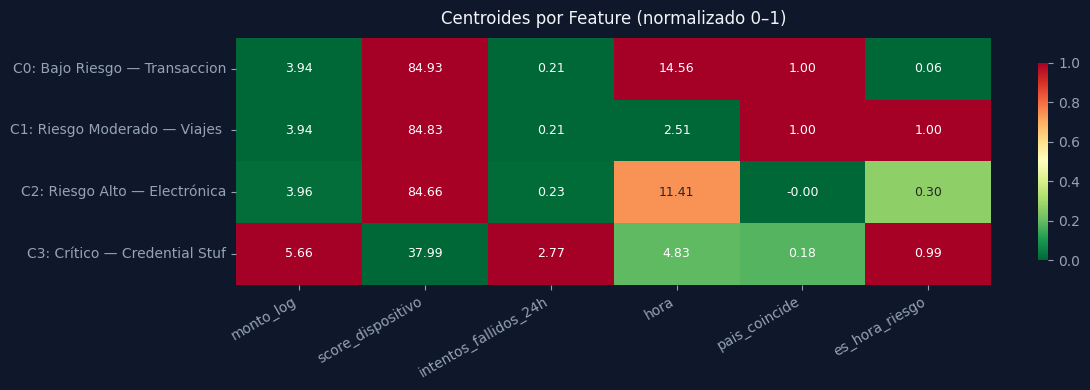

In [13]:
# Heatmap de centroides normalizados
centroides_df = pd.DataFrame(
    centroides_orig,
    columns=FEATURES,
    index=[f'C{c}: {CLUSTER_NAMES[c][:25]}' for c in range(K)]
)
# Normalizar por columna para comparar
centroides_norm = (centroides_df - centroides_df.min()) / (centroides_df.max() - centroides_df.min())

fig, ax = plt.subplots(figsize=(12, 4), facecolor='#0F172A')
sns.heatmap(centroides_norm, annot=centroides_df.round(2), fmt='.2f',
            cmap='RdYlGn_r', ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Centroides por Feature (normalizado 0–1)', color='#F1F5F9', fontsize=12, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Recomendaciones operativas por segmento

La segmentación tiene valor real solo si traduce en acciones distintas para cada grupo. Una respuesta operativa diferenciada por cluster permite priorizar recursos de revisión manual, calibrar umbrales de autenticación adicional y diseñar reglas de alerta proporcionales al riesgo.

| Cluster | Perfil | Tasa fraude aprox. | Acción recomendada |
|---------|--------|--------------------|--------------------|
| C0 | Bajo riesgo — transacciones rutinarias | ~0.01% | Monitoreo estándar, sin fricción adicional |
| C1 | Riesgo moderado — alguna señal aislada | ~0.3% | Revisión si monto supera umbral configurable |
| C2 | Riesgo alto — combinación de señales | ~2% | Autenticación adicional obligatoria |
| C3 | Crítico — múltiples señales simultáneas | ~98% | Bloqueo automático + alerta inmediata al titular |

Esta tabla es el output final de la auditoría: convierte un modelo estadístico en una política de decisión que un equipo operativo puede implementar.

In [14]:
print('=== RESUMEN EJECUTIVO — CLUSTERING DE RIESGO ===')
print(f'Modelo: KMeans | K=4 seleccionado por método del codo')
print(f'Features: {FEATURES}')
print(f'Preprocesamiento: StandardScaler')
print(f'Varianza PCA explicada: {varianza[0]:.1f}% + {varianza[1]:.1f}% = {varianza.sum():.1f}%')
print()
for c in range(K):
    sub  = df[df['cluster']==c]
    print(f'C{c} — {CLUSTER_NAMES[c]}')
    print(f'     {len(sub):,} txns ({len(sub)/len(df)*100:.1f}%) | fraude {sub["target"].mean()*100:.2f}%')
    print(f'     → {CLUSTER_RECS[c]}')
    print()

=== RESUMEN EJECUTIVO — CLUSTERING DE RIESGO ===
Modelo: KMeans | K=4 seleccionado por método del codo
Features: ['monto_log', 'score_dispositivo', 'intentos_fallidos_24h', 'hora', 'pais_coincide', 'es_hora_riesgo']
Preprocesamiento: StandardScaler
Varianza PCA explicada: 28.2% + 22.2% = 50.5%

C0 — Bajo Riesgo — Transacciones Típicas
     34,479 txns (69.0%) | fraude 0.01%
     → Monitoreo estándar. Revisión solo si supera umbral de monto.

C1 — Riesgo Moderado — Viajes y Servicios
     11,408 txns (22.8%) | fraude 0.27%
     → Revisión manual para montos > 500 USD y segunda validación de identidad.

C2 — Riesgo Alto — Electrónica Nocturna Internacional
     3,449 txns (6.9%) | fraude 1.88%
     → Bloqueo preventivo y autenticación adicional obligatoria.

C3 — Crítico — Credential Stuffing
     664 txns (1.3%) | fraude 97.89%
     → Activar challenge tras 2 intentos fallidos. Bloquear tras 3+.

